In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Student Dataset
student_df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\AI_Career_Guidance_Project\Student_Profile_Dataset 3.csv")

# Load Career Dataset
career_df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\AI_Career_Guidance_Project\career_multilabel_dataset final.csv")

# Load Skill Gap Dataset
skill_gap_df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\AI_Career_Guidance_Project\Skill_Gap_Dataset 2.csv")

# Load Learning Roadmap Dataset
roadmap_df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\AI_Career_Guidance_Project\Learning_Roadmap_Dataset.csv")

In [3]:
print("Student Dataset Shape:", student_df.shape)
print("Career Dataset Shape:", career_df.shape)
print("Skill Gap Dataset Shape:", skill_gap_df.shape)
print("Roadmap Dataset Shape:", roadmap_df.shape)

Student Dataset Shape: (1000, 22)
Career Dataset Shape: (2000, 25)
Skill Gap Dataset Shape: (1000, 10)
Roadmap Dataset Shape: (1000, 10)


In [4]:
student_df.head()
career_df.head()
skill_gap_df.head()
roadmap_df.head()

,Student_ID,Full_Name,Target_Career,Gap_Percentage,Priority_Skills,Learning_Stage,Learning_Path,Recommended_Resources,Estimated_Duration,Milestone
0,S0001,Tanya Sharma,Software Engineer,0.0,None - all required skills met,Advanced,No further core skills required - focus on por...,Advanced/Portfolio-building courses,1 week,Job-ready for a Software Engineer role; portfo...
1,S0002,Ananya Verma,Frontend Developer,28.6,Python,Advanced,Python,Python Programming Fundamentals,2 months,Job-ready for a Frontend Developer role; portf...
2,S0003,Naveen Singh,Security Engineer,75.8,"DSA, SQL, Statistics, TensorFlow",Beginner,DSA -> SQL -> Statistics -> TensorFlow,"Data Structures & Algorithms Masterclass, SQL ...",7 months,Foundational skills in place to begin structur...
3,S0004,Karan Rao,DevOps Engineer,79.2,"Python, DSA, Statistics",Intermediate,Python -> DSA -> Statistics,"Python Programming Fundamentals, Data Structur...",7 months,Interview-ready for DevOps Engineer roles afte...
4,S0005,Aman Choudhary,AI Researcher,37.5,"Python, DSA",Intermediate,Python -> DSA,"Python Programming Fundamentals, Data Structur...",3 months,Interview-ready for AI Researcher roles after ...


In [5]:
student_df.tail()
career_df.tail()
skill_gap_df.tail()
roadmap_df.tail()

,Student_ID,Full_Name,Target_Career,Gap_Percentage,Priority_Skills,Learning_Stage,Learning_Path,Recommended_Resources,Estimated_Duration,Milestone
995,S0996,Tarun Yadav,Machine Learning Engineer,40.0,"Python, Machine Learning",Intermediate,Python -> Machine Learning,"Python Programming Fundamentals, Machine Learn...",3 months,Interview-ready for Machine Learning Engineer ...
996,S0997,Swati Saxena,Cloud Engineer,0.0,None - all required skills met,Advanced,No further core skills required - focus on por...,Advanced/Portfolio-building courses,1 week,Job-ready for a Cloud Engineer role; portfolio...
997,S0998,Riya Bansal,AI Researcher,20.8,TensorFlow,Advanced,TensorFlow,Deep Learning with TensorFlow,6 weeks,Job-ready for a AI Researcher role; portfolio ...
998,S0999,Lavanya Singh,Machine Learning Engineer,12.0,SQL,Advanced,SQL,SQL for Data Analysis,3 weeks,Job-ready for a Machine Learning Engineer role...
999,S1000,Aditi Joshi,Backend Developer,58.3,"SQL, Python",Intermediate,SQL -> Python,"SQL for Data Analysis, Python Programming Fund...",5 months,Interview-ready for Backend Developer roles af...


In [6]:
print(student_df.columns)
print(career_df.columns)
print(skill_gap_df.columns)
print(roadmap_df.columns)

Index(['Student_ID', 'Full_Name', 'Gender', 'Age', 'GPA', 'Degree_Level',
       'Current_Status', 'Project_Count', 'Years_of_Experience',
       'Employment_Status', 'Internship_Count', 'Python', 'SQL',
       'Machine_Learning', 'TensorFlow', 'DSA', 'Statistics', 'Interest',
       'Certification_Count', 'Preferred_Industry', 'Career_Goal',
       'Target_Career'],
      dtype='object')
Index(['age', 'gender', 'degree_level', 'field_of_study', 'gpa',
       'years_experience', 'python', 'java', 'c_cpp', 'sql',
       'machine_learning', 'data_analysis', 'cloud_computing', 'cybersecurity',
       'web_development', 'devops', 'networking', 'communication',
       'leadership', 'problem_solving', 'teamwork', 'adaptability',
       'recommended_job_1', 'recommended_job_2', 'recommended_job_3'],
      dtype='object')
Index(['Student_ID', 'Full_Name', 'Target_Career', 'Career_Goal',
       'Current_Skills', 'Required_Skills', 'Gap_Percentage',
       'Recommended_Level', 'Estimated_Hours',

In [7]:
student_df.info()
career_df.info()
skill_gap_df.info()
roadmap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           1000 non-null   object 
 1   Full_Name            1000 non-null   object 
 2   Gender               1000 non-null   object 
 3   Age                  1000 non-null   int64  
 4   GPA                  1000 non-null   float64
 5   Degree_Level         1000 non-null   object 
 6   Current_Status       1000 non-null   object 
 7   Project_Count        1000 non-null   int64  
 8   Years_of_Experience  1000 non-null   float64
 9   Employment_Status    1000 non-null   object 
 10  Internship_Count     1000 non-null   int64  
 11  Python               1000 non-null   int64  
 12  SQL                  1000 non-null   int64  
 13  Machine_Learning     1000 non-null   int64  
 14  TensorFlow           1000 non-null   int64  
 15  DSA                  1000 non-null   in

In [8]:
student_df.describe()
career_df.describe()
skill_gap_df.describe()
roadmap_df.describe()

,Gap_Percentage
count,1000.000000
mean,29.916700
std,22.775596
min,0.000000
25%,13.825000
50%,28.000000
75%,43.650000
max,100.000000


In [9]:
student_df.isnull().sum()
career_df.isnull().sum()
skill_gap_df.isnull().sum()
roadmap_df.isnull().sum()


Student_ID               0
Full_Name                0
Target_Career            0
Gap_Percentage           0
Priority_Skills          0
Learning_Stage           0
Learning_Path            0
Recommended_Resources    0
Estimated_Duration       0
Milestone                0
dtype: int64

In [10]:
student_df.duplicated().sum()
career_df.duplicated().sum()
skill_gap_df.duplicated().sum()
roadmap_df.duplicated().sum()

np.int64(0)

In [ ]:
## Data Cleaning Summary

- Checked for missing values in all four datasets.
- No missing values were found.
- Checked for duplicate records in all four datasets.
- No duplicate records were found.
- Verified that all column data types are appropriate.
- The datasets are clean and ready for feature engineering.

In [10]:
numerical_columns = [
    'Age',
    'GPA',
    'Project_Count',
    'Years_of_Experience',
    'Internship_Count',
    'Certification_Count'
]

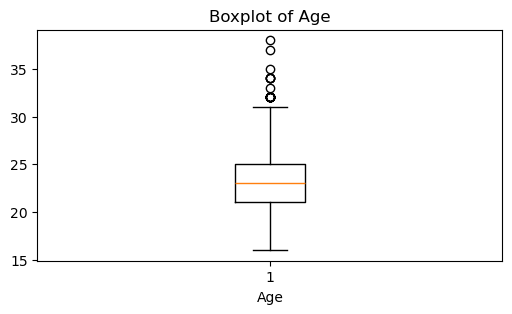

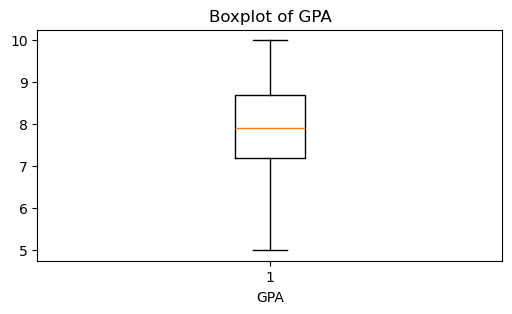

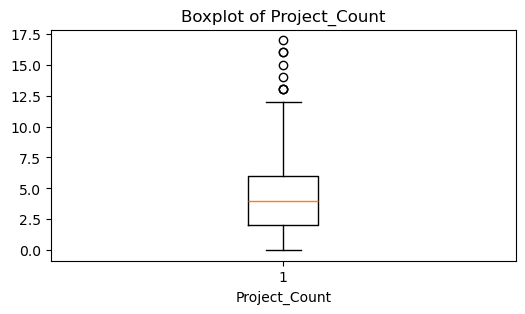

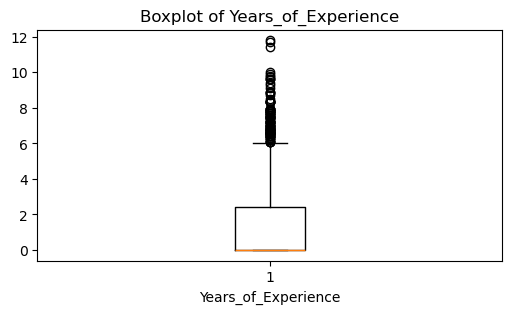

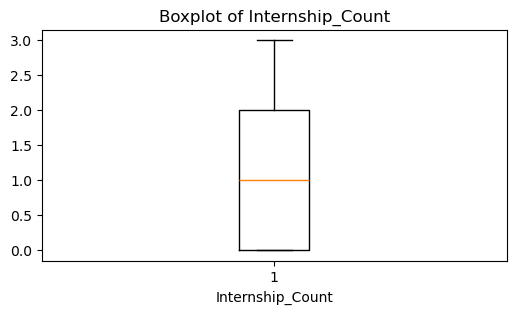

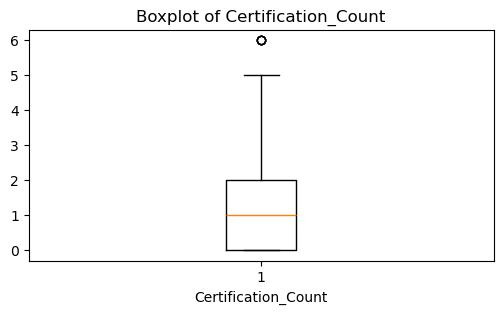

In [11]:
import matplotlib.pyplot as plt

for column in numerical_columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(student_df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [ ]:

### Outlier Detection

Boxplots were used to detect outliers in the numerical features.

The following columns showed a few outliers:
- Age
- Project_Count
- Years_of_Experience
- Certification_Count

These values were inspected and found to be valid observations rather than errors. 
Therefore, no outlier removal was performed.

In [13]:
# Create Skill Score Feature

student_df['Skill_Score'] = (
    student_df['Python'] +
    student_df['SQL'] +
    student_df['Machine_Learning'] +
    student_df['TensorFlow'] +
    student_df['DSA'] +
    student_df['Statistics']
)

In [14]:
student_df[['Python',
            'SQL',
            'Machine_Learning',
            'TensorFlow',
            'DSA',
            'Statistics',
            'Skill_Score']].head()

,Python,SQL,Machine_Learning,TensorFlow,DSA,Statistics,Skill_Score
0,4,4,1,1,5,2,17
1,1,4,1,1,3,1,11
2,3,1,1,1,4,1,11
3,3,3,1,1,1,1,10
4,4,2,5,5,3,5,24


In [15]:
student_df['Skill_Score'].describe()

count    1000.000000
mean       16.898000
std         4.534331
min         7.000000
25%        14.000000
50%        16.000000
75%        20.000000
max        28.000000
Name: Skill_Score, dtype: float64

In [ ]:
### Skill Score Feature

A new feature named **Skill_Score** was created by summing the binary technical skill columns.

This feature represents the total number of technical skills possessed by a student.

It provides the machine learning model with a concise measure of technical proficiency, 
which can improve career recommendation accuracy.

In [16]:
# Create Experience Level Feature

def experience_level(years):
    if years <= 1:
        return "Beginner"
    elif years <= 3:
        return "Intermediate"
    else:
        return "Advanced"

student_df["Experience_Level"] = student_df["Years_of_Experience"].apply(experience_level)

In [17]:
student_df[['Years_of_Experience','Experience_Level']].head(10)

,Years_of_Experience,Experience_Level
0,0.0,Beginner
1,0.0,Beginner
2,0.0,Beginner
3,0.0,Beginner
4,0.0,Beginner
5,1.0,Beginner
6,0.0,Beginner
7,0.0,Beginner
8,7.5,Advanced
9,8.3,Advanced


In [18]:
student_df['Experience_Level'].value_counts()

Experience_Level
Beginner        678
Advanced        225
Intermediate     97
Name: count, dtype: int64

In [ ]:
### Experience Level Feature

A new feature called **Experience_Level** was created from the **Years_of_Experience** column.

The continuous values were converted into three categories:

- Beginner (≤ 1 year)
- Intermediate (1–3 years)
- Advanced (> 3 years)

This feature makes it easier for the machine learning model to understand the student's experience level.

In [19]:
student_df['GPA'].describe()

count    1000.000000
mean        7.929900
std         1.049561
min         5.000000
25%         7.200000
50%         7.900000
75%         8.700000
max        10.000000
Name: GPA, dtype: float64

In [20]:
# Create GPA Category Feature

def gpa_category(gpa):
    if gpa < 6.5:
        return "Low"
    elif gpa < 7.5:
        return "Average"
    elif gpa < 8.5:
        return "Good"
    else:
        return "Excellent"

student_df["GPA_Category"] = student_df["GPA"].apply(gpa_category)

In [21]:
student_df[['GPA', 'GPA_Category']].head(10)

,GPA,GPA_Category
0,8.2,Good
1,7.8,Good
2,10.0,Excellent
3,7.2,Average
4,6.8,Average
5,8.8,Excellent
6,9.1,Excellent
7,7.8,Good
8,7.0,Average
9,7.8,Good


In [22]:
student_df['GPA_Category'].value_counts()

GPA_Category
Good         361
Excellent    317
Average      236
Low           86
Name: count, dtype: int64

In [ ]:
### GPA Category Feature

A new feature called **GPA_Category** was created from the GPA column.

The GPA values were categorized into four levels:

- Low (< 6.5)
- Average (6.5 – 7.49)
- Good (7.5 – 8.49)
- Excellent (≥ 8.5)

This feature helps the machine learning model understand a student's academic performance more effectively.

In [23]:
student_df['Project_Count'].describe()

count    1000.000000
mean        4.345000
std         2.727896
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        17.000000
Name: Project_Count, dtype: float64

In [24]:
# Create Project Level Feature

def project_level(projects):
    if projects <= 2:
        return "Beginner"
    elif projects <= 5:
        return "Intermediate"
    else:
        return "Advanced"

student_df["Project_Level"] = student_df["Project_Count"].apply(project_level)

In [25]:
student_df[['Project_Count','Project_Level']].head(10)

,Project_Count,Project_Level
0,2,Beginner
1,0,Beginner
2,6,Advanced
3,2,Beginner
4,4,Intermediate
5,5,Intermediate
6,7,Advanced
7,5,Intermediate
8,8,Advanced
9,9,Advanced


In [26]:
student_df['Project_Level'].value_counts()

Project_Level
Intermediate    429
Advanced        314
Beginner        257
Name: count, dtype: int64

In [ ]:
### Project Level Feature

A new feature called **Project_Level** was created from the **Project_Count** column.

The project counts were categorized into:

- Beginner (0–2 Projects)
- Intermediate (3–5 Projects)
- Advanced (More than 5 Projects)

This feature represents the student's practical project experience, which is an important factor in career recommendation.

In [27]:
student_df['Certification_Count'].describe()



count    1000.00000
mean        1.30500
std         1.13722
min         0.00000
25%         0.00000
50%         1.00000
75%         2.00000
max         6.00000
Name: Certification_Count, dtype: float64

In [28]:
# Create Certification Level Feature

def certification_level(certifications):
    if certifications == 0:
        return "None"
    elif certifications <= 2:
        return "Basic"
    else:
        return "Advanced"

student_df["Certification_Level"] = student_df["Certification_Count"].apply(certification_level)

In [29]:
student_df[['Certification_Count','Certification_Level']].head(10)

,Certification_Count,Certification_Level
0,0,None
1,1,Basic
2,0,None
3,6,Advanced
4,0,None
5,1,Basic
6,1,Basic
7,1,Basic
8,3,Advanced
9,2,Basic


In [30]:
student_df['Certification_Level'].value_counts()

Certification_Level
Basic       584
None        274
Advanced    142
Name: count, dtype: int64

In [ ]:
### Certification Level Feature

A new feature called **Certification_Level** was created from the **Certification_Count** column.

The certification counts were categorized into:

- None (0 Certifications)
- Basic (1–2 Certifications)
- Advanced (More than 2 Certifications)

This feature represents the student's certification achievements.

In [31]:
from sklearn.preprocessing import LabelEncoder


In [32]:
le = LabelEncoder()

In [33]:
student_df.select_dtypes(include=['object']).columns

Index(['Student_ID', 'Full_Name', 'Gender', 'Degree_Level', 'Current_Status',
       'Employment_Status', 'Interest', 'Preferred_Industry', 'Career_Goal',
       'Target_Career', 'Experience_Level', 'GPA_Category', 'Project_Level',
       'Certification_Level'],
      dtype='object')

In [34]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Columns to encode
categorical_columns = [
    'Gender',
    'Degree_Level',
    'Current_Status',
    'Employment_Status',
    'Interest',
    'Preferred_Industry',
    'Career_Goal',
    'Experience_Level',
    'GPA_Category',
    'Project_Level',
    'Certification_Level'
]

# Reload the original dataset if needed
student_df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\AI_Career_Guidance_Project\Student_Profile_Dataset 3.csv")

# Recreate the engineered features
student_df['Skill_Score'] = (
    student_df['Python'] +
    student_df['SQL'] +
    student_df['Machine_Learning'] +
    student_df['TensorFlow'] +
    student_df['DSA'] +
    student_df['Statistics']
)

def experience_level(exp):
    if exp < 2:
        return "Beginner"
    elif exp < 5:
        return "Intermediate"
    else:
        return "Advanced"

student_df['Experience_Level'] = student_df['Years_of_Experience'].apply(experience_level)

def gpa_category(gpa):
    if gpa < 6.5:
        return "Low"
    elif gpa < 7.5:
        return "Average"
    elif gpa < 8.5:
        return "Good"
    else:
        return "Excellent"

student_df['GPA_Category'] = student_df['GPA'].apply(gpa_category)

def project_level(projects):
    if projects <= 2:
        return "Beginner"
    elif projects <= 5:
        return "Intermediate"
    else:
        return "Advanced"

student_df['Project_Level'] = student_df['Project_Count'].apply(project_level)

def certification_level(certifications):
    if certifications == 0:
        return "None"
    elif certifications <= 2:
        return "Basic"
    else:
        return "Advanced"

student_df['Certification_Level'] = student_df['Certification_Count'].apply(certification_level)

# Create and store encoders
input_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    encoder.fit(student_df[column])
    input_encoders[column] = encoder

# Save encoders
with open("input_encoders.pkl", "wb") as file:
    pickle.dump(input_encoders, file)

print("input_encoders.pkl created successfully!")

input_encoders.pkl created successfully!


In [35]:
student_df.head()

,Student_ID,Full_Name,Gender,Age,GPA,Degree_Level,Current_Status,Project_Count,Years_of_Experience,Employment_Status,...,Interest,Certification_Count,Preferred_Industry,Career_Goal,Target_Career,Skill_Score,Experience_Level,GPA_Category,Project_Level,Certification_Level
0,S0001,Tanya Sharma,Female,19,8.2,Bachelor,Student,2,0.0,Intern,...,Web Development,0,Software Development,Backend Developer,Software Engineer,17,Beginner,Good,Beginner,None
1,S0002,Ananya Verma,Female,18,7.8,Diploma,Student,0,0.0,Unemployed,...,Web Development,1,Software Development,Full Stack Developer,Frontend Developer,11,Beginner,Good,Beginner,Basic
2,S0003,Naveen Singh,Male,27,10.0,Master,Student,6,0.0,Unemployed,...,Cybersecurity,0,Artificial Intelligence,Security Engineer,Security Engineer,11,Beginner,Excellent,Advanced,None
3,S0004,Karan Rao,Male,22,7.2,Bachelor,Graduate,2,0.0,Full-Time,...,DevOps,6,Cloud Computing,DevOps Engineer,DevOps Engineer,10,Beginner,Average,Beginner,Advanced
4,S0005,Aman Choudhary,Male,22,6.8,Bachelor,Graduate,4,0.0,Full-Time,...,Artificial Intelligence,0,Software Development,AI Researcher,AI Researcher,24,Beginner,Average,Intermediate,None


In [36]:
# Remove identifier columns

student_df = student_df.drop(['Student_ID', 'Full_Name'], axis=1)

In [37]:
# Features (X) and Target (y)

X = student_df.drop('Target_Career', axis=1)
y = student_df['Target_Career']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (800, 24)
Testing Features: (200, 24)
Training Target: (800,)
Testing Target: (200,)


In [40]:
# Create train dataset

train_df = X_train.copy()
train_df['Target_Career'] = y_train

In [41]:
# Create test dataset

test_df = X_test.copy()
test_df['Target_Career'] = y_test

In [42]:
train_df.to_csv("train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)

In [43]:
train_df.to_excel("train_dataset.xlsx", index=False)
test_df.to_excel("test_dataset.xlsx", index=False)